**Data Collection**

Training and Testing Data are given by Kaggle.

**Load the train and test data using pandas**

In [1]:
import pandas as pd

train_data= pd.read_csv('train.csv')
test_data= pd.read_csv('test.csv')

**Data Dictionary**\
Survived: 0 = No, 1 = Yes\
pclass: Ticket class 1 = 1st, 2 = 2nd, 3 = 3rd\
sibsp: number of siblings / spouses aboard the Titanic\
parch: number of parents / children aboard the Titanic\
ticket: Ticket number\
cabin: Cabin number\
embarked: Port of Embarkation C = Cherbourg, Q = Queenstown, S = Southampton

**Exploratory Data Analysis**

In [2]:
# Show the first five rows in the train dataset
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
train_data.shape

(891, 12)

In [5]:
test_data.shape

(418, 11)

Check for null values

In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [8]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
test_data.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

**Data Visualization**

In [10]:
import matplotlib.pyplot as plt
# %matplotlib inline
import seaborn as sns
sns.set() # setting seaborn default for plots

In [11]:
def bar_chart(feature):
    survived = train_data[train_data['Survived']==1][feature].value_counts()
    dead = train_data[train_data['Survived']==0][feature].value_counts()
    df = pd.DataFrame([survived,dead])
    df.index = ['Survived','Died']
    df.plot(kind='bar',stacked=True, figsize=(10,5))

**Categorical Features**\
Pclass\
Sex\
SibSp\
Parch\
Embarked\
Cabin

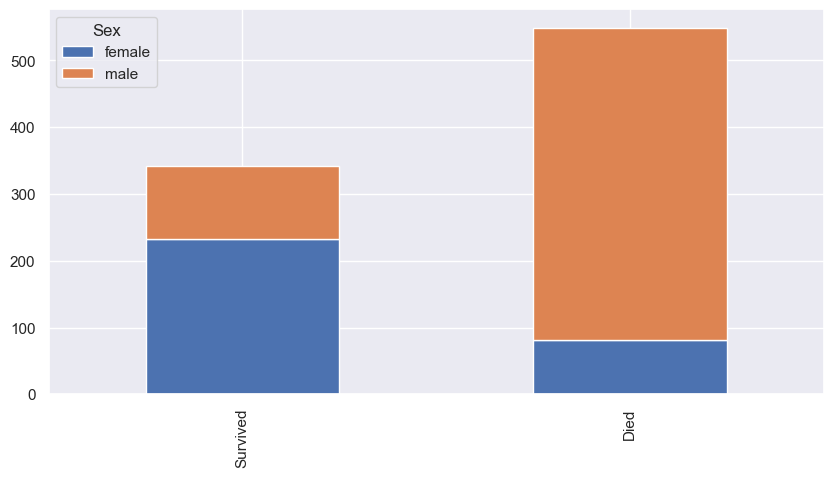

In [12]:
bar_chart('Sex')

Females are more likely to survive than males

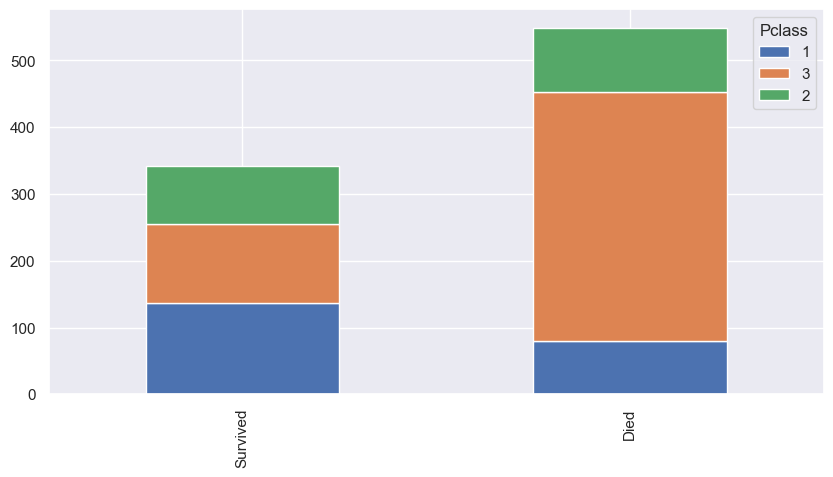

In [13]:
bar_chart('Pclass')

Passengers in first class are more likely to survive than those in other classes\
Paasengers in third class are more likely to die than those in other classes

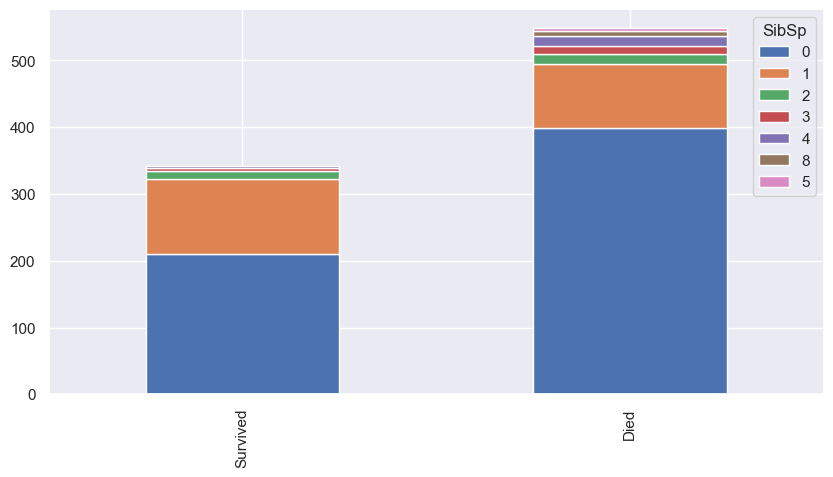

In [14]:
bar_chart('SibSp')

A person who boarded with more than 2 siblings or spouse more likely survived\
A person who boarded without a siblings or spouse more likely died

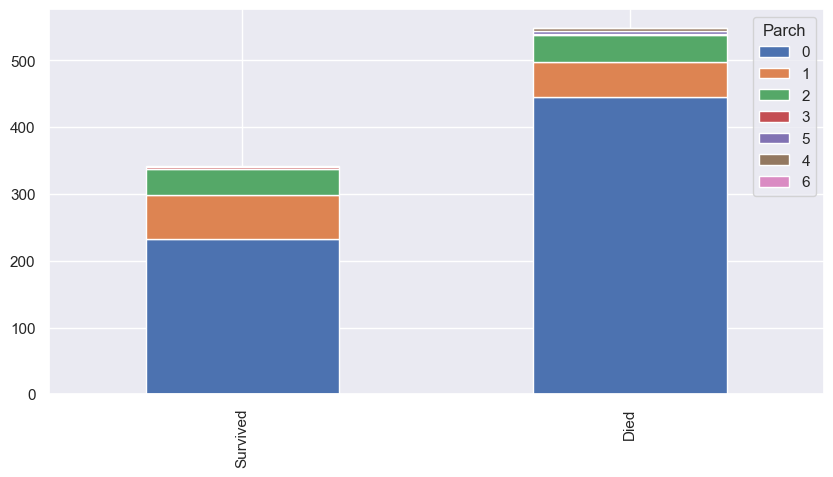

In [15]:
bar_chart('Parch')

A person who boarded with more than 2 parents or children more likely survived\
A person who boarded alone more likely died

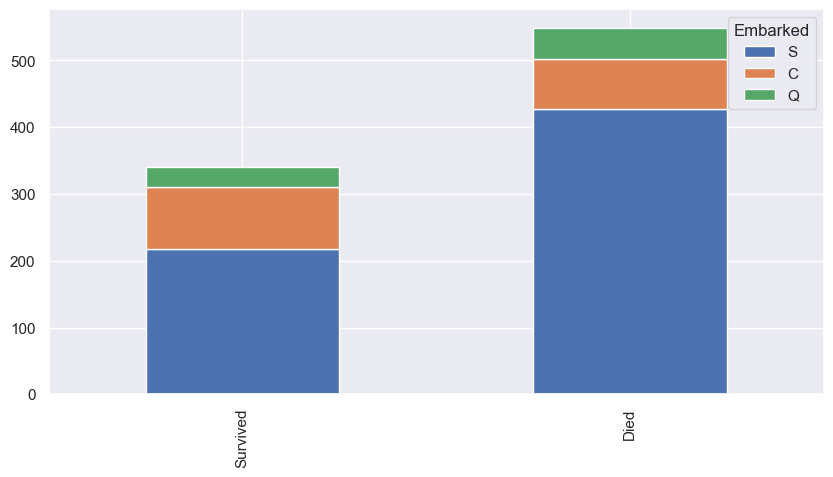

In [16]:
bar_chart('Embarked')

A person who boarded from C slightly more likely survived\
A person who boarded from Q more likely died\
A person who boarded from S more likely died

**Feature Engineering**\
Creating features that make the ML algorithm work.

In [17]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
# Combine the train and test data
train_test_data = [train_data, test_data] 

for dataset in train_test_data:
    dataset['Title'] = dataset['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [19]:
train_data['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [20]:
test_data['Title'].value_counts()

Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

**Title Mapping**\
Mr: 0\
Miss: 1\
Mrs: 2\
Others: 3\
Map the titles, create a new column for them and drop the name column since it's not a necessary feature. 

In [21]:
title_mapping = {"Mr": 0, "Miss": 1, "Mrs": 2, 
                 "Master": 3, "Dr": 3, "Rev": 3, "Col": 3, "Major": 3, "Mlle": 3,"Countess": 3,
                 "Ms": 3, "Lady": 3, "Jonkheer": 3, "Don": 3, "Dona" : 3, "Mme": 3,"Capt": 3,"Sir": 3 }
for dataset in train_test_data:
    dataset['Title'] = dataset['Title'].map(title_mapping)

In [22]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,2
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,2


In [23]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


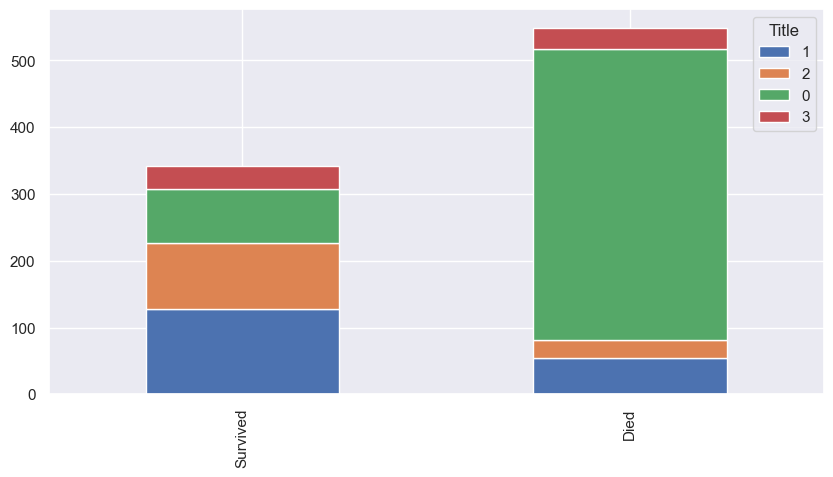

In [24]:
bar_chart('Title')

In [25]:
train_data.drop('Name', axis=1, inplace=True)
test_data.drop('Name', axis=1, inplace=True)

In [26]:
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S,0


In [27]:
test_data.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,892,3,male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,female,47.0,1,0,363272,7.0000,NaN,S,2
2,894,2,male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,female,22.0,1,1,3101298,12.2875,NaN,S,2


**Sex Mapping**\
Male: 0\
Female: 1

In [28]:
sex_mapping = {"male": 0, "female": 1}
for dataset in train_test_data:
    dataset['Sex'] = dataset['Sex'].map(sex_mapping)

In [29]:
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,1,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,1,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,0,35.0,0,0,373450,8.0500,NaN,S,0


In [30]:
test_data.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,892,3,0,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,1,47.0,1,0,363272,7.0000,NaN,S,2
2,894,2,0,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,0,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,1,22.0,1,1,3101298,12.2875,NaN,S,2


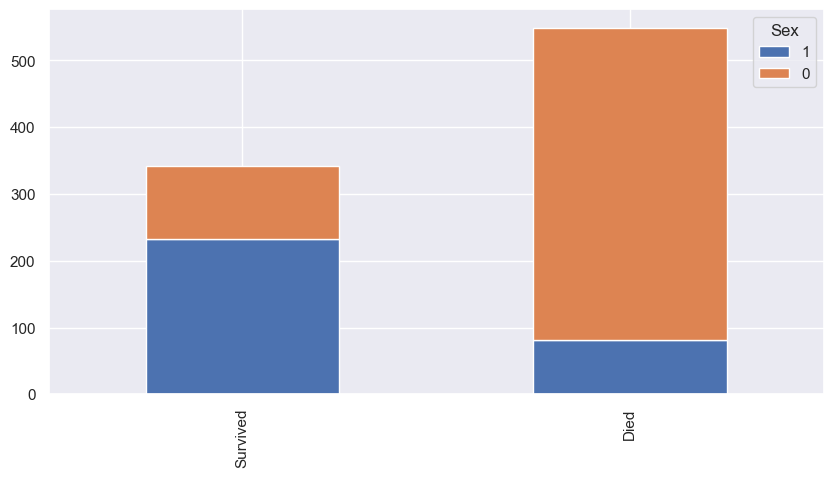

In [31]:
bar_chart('Sex')

**Age**\
Fill missing age with median age for each title (Mr, Mrs, Miss, Others)

In [32]:
train_data["Age"] = train_data["Age"].fillna(train_data.groupby("Title")["Age"].transform("median"))
test_data["Age"] =test_data["Age"].fillna(test_data.groupby("Title")["Age"].transform("median"))

In [33]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Title            0
dtype: int64

In [34]:
test_data.isnull().sum()

PassengerId      0
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
Title            0
dtype: int64

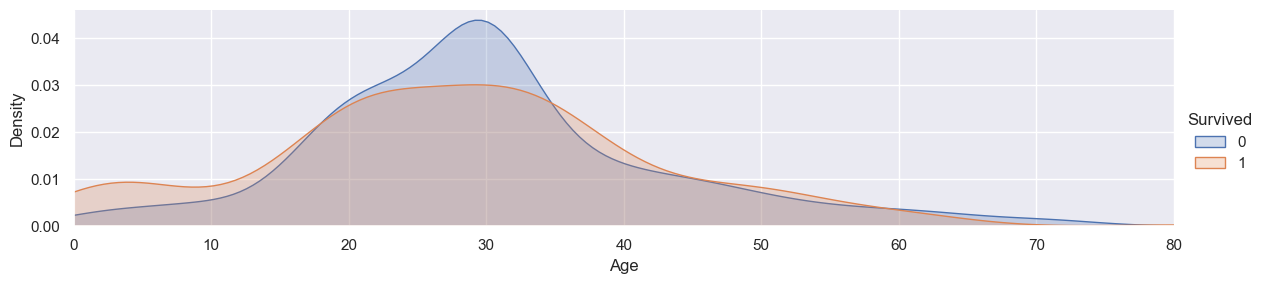

In [35]:
facet = sns.FacetGrid(train_data, hue="Survived",aspect=4)
facet.map(sns.kdeplot,'Age',fill= True)
facet.set(xlim=(0, train_data['Age'].max()))
facet.add_legend()
 
plt.show() 

**Binning**\
Converting Numerical Age to Categorical Variable\
feature vector map:\
child: 0\
young: 1\
adult: 2\
mid-age: 3\
senior: 4

In [36]:
bins = [-float('inf'), 16, 26, 36, 62, float('inf')]
labels = [0, 1, 2, 3, 4]

for dataset in train_test_data:
    dataset['Age'] = pd.cut(dataset['Age'], bins=bins, labels=labels)


In [37]:
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,1,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,1,3,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,1,1,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,1,2,1,0,113803,53.1000,C123,S,2
4,5,0,3,0,2,0,0,373450,8.0500,NaN,S,0


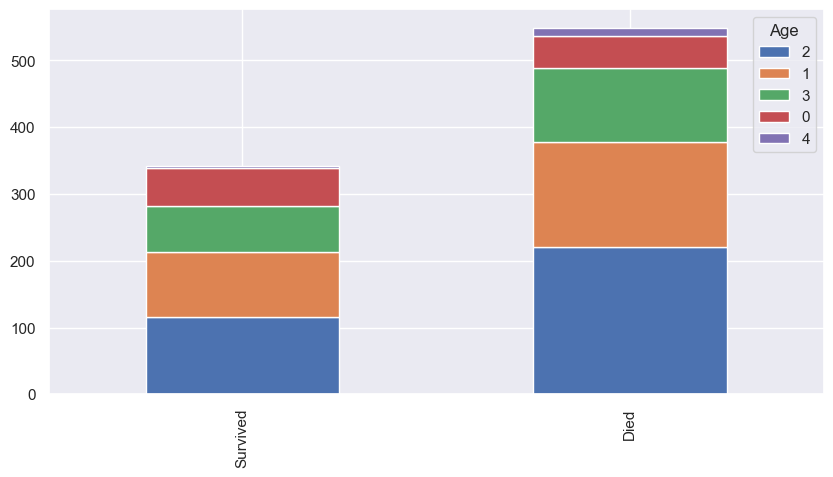

In [38]:
bar_chart('Age')

**Embarked**

<Axes: >

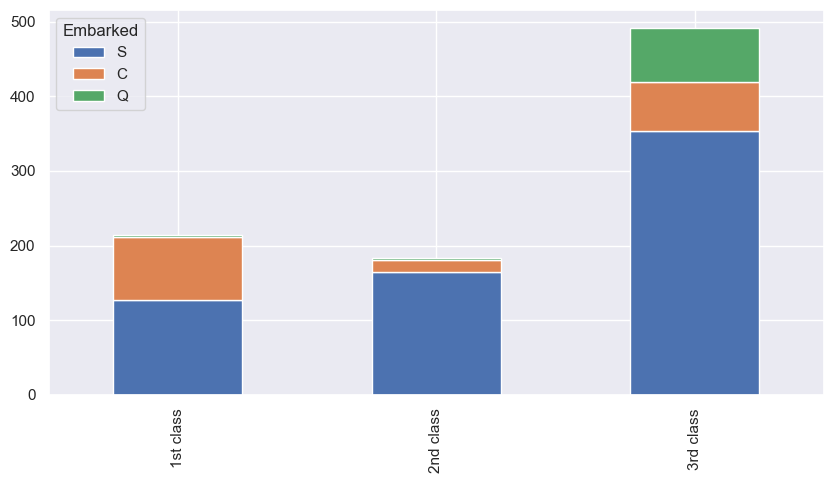

In [39]:
Pclass1 = train_data[train_data['Pclass']==1]['Embarked'].value_counts()
Pclass2 = train_data[train_data['Pclass']==2]['Embarked'].value_counts()
Pclass3 = train_data[train_data['Pclass']==3]['Embarked'].value_counts()
df = pd.DataFrame([Pclass1, Pclass2, Pclass3])
df.index = ['1st class','2nd class', '3rd class']
df.plot(kind='bar',stacked=True, figsize=(10,5))

More than 50 & of all classes Embarked from S, therefore we will fill all the missing Embarks with S

In [40]:
for dataset in train_test_data:
    dataset['Embarked'] = dataset['Embarked'].fillna('S')

In [41]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Title            0
dtype: int64

Map Embarking

In [42]:
embarked_mapping = {"S": 0, "C": 1, "Q": 2}
for dataset in train_test_data:
    dataset['Embarked'] = dataset['Embarked'].map(embarked_mapping)

In [43]:
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,1,1,0,A/5 21171,7.2500,NaN,0,0
1,2,1,1,1,3,1,0,PC 17599,71.2833,C85,1,2
2,3,1,3,1,1,0,0,STON/O2. 3101282,7.9250,NaN,0,1
3,4,1,1,1,2,1,0,113803,53.1000,C123,0,2
4,5,0,3,0,2,0,0,373450,8.0500,NaN,0,0


**Fare**

In [44]:
test_data.isnull().sum()

PassengerId      0
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
Title            0
dtype: int64

In [45]:
test_data["Fare"].fillna(test_data.groupby("Pclass")["Fare"].transform("median"), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_27164\966083978.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data["Fare"].fillna(test_data.groupby("Pclass")["Fare"].transform("median"), inplace=True)


In [46]:
test_data.isnull().sum()

PassengerId      0
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
Title            0
dtype: int64

In [47]:
train_data['Fare'] = pd.qcut(train_data['Fare'], 4, labels=[0, 1, 2, 3])
test_data['Fare'] = pd.qcut(test_data['Fare'], 4, labels=[0, 1, 2, 3])

In [48]:
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,1,1,0,A/5 21171,0,NaN,0,0
1,2,1,1,1,3,1,0,PC 17599,3,C85,1,2
2,3,1,3,1,1,0,0,STON/O2. 3101282,1,NaN,0,1
3,4,1,1,1,2,1,0,113803,3,C123,0,2
4,5,0,3,0,2,0,0,373450,1,NaN,0,0


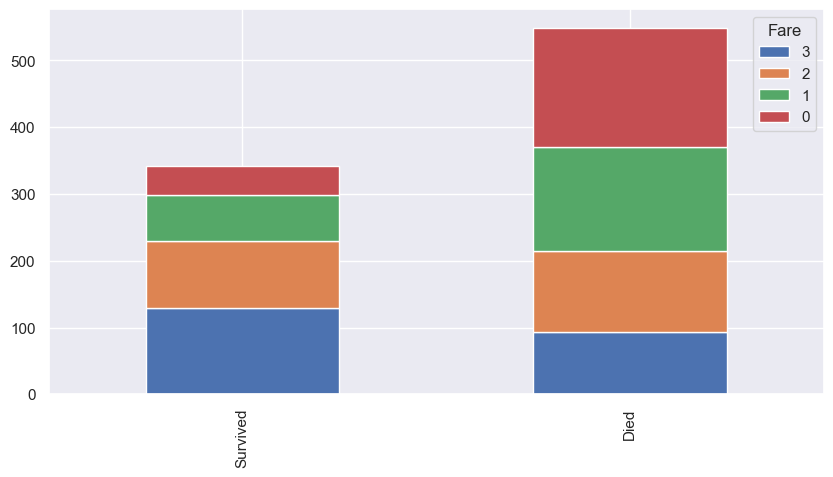

In [49]:
bar_chart('Fare')

**Cabin**

In [51]:
train_data.Cabin.value_counts()

Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: count, Length: 147, dtype: int64

In [52]:
for dataset in train_test_data:
    dataset['Cabin'] = dataset['Cabin'].str[:1]

<Axes: >

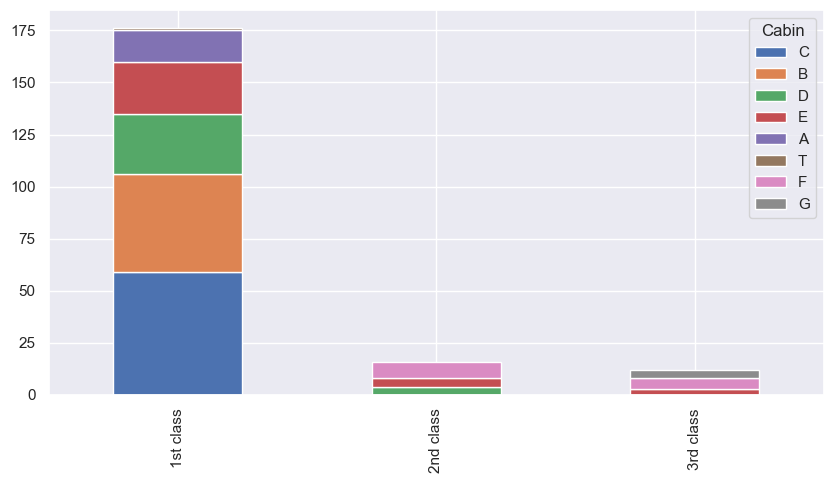

In [54]:
Pclass1 = train_data[train_data['Pclass']==1]['Cabin'].value_counts()
Pclass2 = train_data[train_data['Pclass']==2]['Cabin'].value_counts()
Pclass3 = train_data[train_data['Pclass']==3]['Cabin'].value_counts()
df = pd.DataFrame([Pclass1, Pclass2, Pclass3])
df.index = ['1st class','2nd class', '3rd class']
df.plot(kind='bar',stacked=True, figsize=(10,5))

Cabin Mapping

In [55]:
cabin_mapping = {"A": 0, "B": 0.4, "C": 0.8, "D": 1.2, "E": 1.6, "F": 2, "G": 2.4, "T": 2.8}
for dataset in train_test_data:
    dataset['Cabin'] = dataset['Cabin'].map(cabin_mapping)

In [57]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Title            0
dtype: int64

Fill the missing Values in Cabin with the median Value

In [59]:
train_data["Cabin"].fillna(train_data.groupby("Pclass")["Cabin"].transform("median"), inplace=True)
test_data["Cabin"].fillna(test_data.groupby("Pclass")["Cabin"].transform("median"), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_27164\3833235288.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data["Cabin"].fillna(train_data.groupby("Pclass")["Cabin"].transform("median"), inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_27164\3833235288.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are 

In [60]:
train_data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Title          0
dtype: int64

**Family Size**\
Combine the SibSp and Parch columns to get one column called FamilySize

In [62]:
train_data["FamilySize"] = train_data["SibSp"] + train_data["Parch"] + 1
test_data["FamilySize"] = test_data["SibSp"] + test_data["Parch"] + 1

(0.0, 11.0)

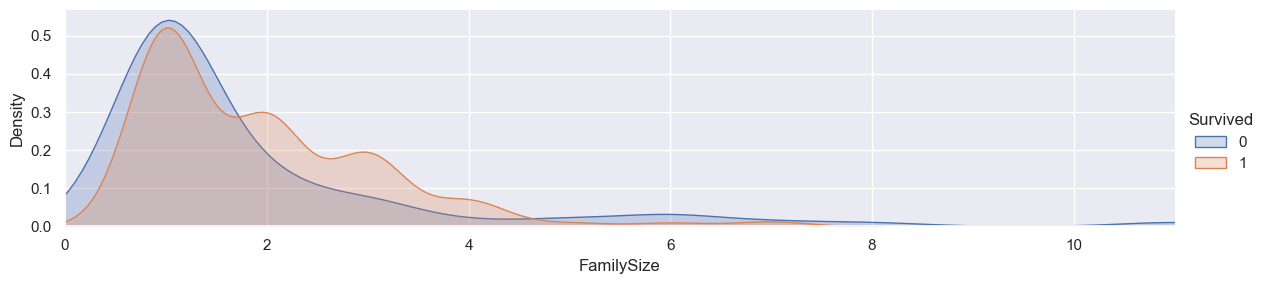

In [66]:
facet = sns.FacetGrid(train_data, hue="Survived",aspect=4)
facet.map(sns.kdeplot,'FamilySize',fill= True)
facet.set(xlim=(0, train_data['FamilySize'].max()))
facet.add_legend()
plt.xlim(0)

Fmily Size Mapping

In [67]:
family_mapping = {1: 0, 2: 0.4, 3: 0.8, 4: 1.2, 5: 1.6, 6: 2, 7: 2.4, 8: 2.8, 9: 3.2, 10: 3.6, 11: 4}
for dataset in train_test_data:
    dataset['FamilySize'] = dataset['FamilySize'].map(family_mapping)

In [68]:
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize
0,1,0,3,0,1,1,0,A/5 21171,0,2.0,0,0,0.4
1,2,1,1,1,3,1,0,PC 17599,3,0.8,1,2,0.4
2,3,1,3,1,1,0,0,STON/O2. 3101282,1,2.0,0,1,0.0
3,4,1,1,1,2,1,0,113803,3,0.8,0,2,0.4
4,5,0,3,0,2,0,0,373450,1,2.0,0,0,0.0


Drop the Unnecessary Columns

In [70]:
features_drop = ['Ticket', 'SibSp', 'Parch']
train_data = train_data.drop(features_drop, axis=1)
test_data = test_data.drop(features_drop, axis=1)
train_data = train_data.drop(['PassengerId'], axis=1)

In [71]:
train_data.head()

,Survived,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
0,0,3,0,1,0,2.0,0,0,0.4
1,1,1,1,3,3,0.8,1,2,0.4
2,1,3,1,1,1,2.0,0,1,0.0
3,1,1,1,2,3,0.8,0,2,0.4
4,0,3,0,2,1,2.0,0,0,0.0


In [74]:
train_df= train_data.drop('Survived', axis=1)
target = train_data['Survived']

train_df.shape, target.shape

((891, 8), (891,))

In [75]:
train_df.head()

,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
0,3,0,1,0,2.0,0,0,0.4
1,1,1,3,3,0.8,1,2,0.4
2,3,1,1,1,2.0,0,1,0.0
3,1,1,2,3,0.8,0,2,0.4
4,3,0,2,1,2.0,0,0,0.0


**Modelling**

In [76]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

import numpy as np

In [77]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    int64   
 2   Sex         891 non-null    int64   
 3   Age         891 non-null    category
 4   Fare        891 non-null    category
 5   Cabin       891 non-null    float64 
 6   Embarked    891 non-null    int64   
 7   Title       891 non-null    int64   
 8   FamilySize  891 non-null    float64 
dtypes: category(2), float64(2), int64(5)
memory usage: 51.0 KB


In [78]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Pclass      891 non-null    int64   
 1   Sex         891 non-null    int64   
 2   Age         891 non-null    category
 3   Fare        891 non-null    category
 4   Cabin       891 non-null    float64 
 5   Embarked    891 non-null    int64   
 6   Title       891 non-null    int64   
 7   FamilySize  891 non-null    float64 
dtypes: category(2), float64(2), int64(4)
memory usage: 44.0 KB


**K-fold**

In [79]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
k_fold = KFold(n_splits=10, shuffle=True, random_state=42)

**KNN**

In [92]:
clf = KNeighborsClassifier(n_neighbors =29 )
scoring = 'accuracy'
score = cross_val_score(clf, train_df, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.78888889 0.78651685 0.82022472 0.75280899 0.83146067 0.85393258
 0.76404494 0.79775281 0.74157303 0.86516854]


In [93]:
# Score
int(round(np.mean(score)*100,2))

80

**Decision Tree**

In [94]:
clf = DecisionTreeClassifier()
scoring = 'accuracy'
score = cross_val_score(clf, train_df, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.82222222 0.7752809  0.73033708 0.78651685 0.80898876 0.80898876
 0.75280899 0.74157303 0.82022472 0.92134831]


In [95]:
# Score
int(round(np.mean(score)*100,2))

79

**Random Forest**

In [97]:
clf = RandomForestClassifier(n_estimators=29)
scoring = 'accuracy'
score = cross_val_score(clf, train_df, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.82222222 0.84269663 0.74157303 0.82022472 0.80898876 0.84269663
 0.79775281 0.79775281 0.80898876 0.92134831]


In [98]:
# Score
int(round(np.mean(score)*100,2))

82

**SVM**

In [100]:
clf = SVC()
scoring = 'accuracy'
score = cross_val_score(clf, train_df, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.85555556 0.80898876 0.85393258 0.78651685 0.86516854 0.86516854
 0.7752809  0.83146067 0.7752809  0.8988764 ]


In [101]:
# Score
int(round(np.mean(score)*100,2))

83

**Naive Bayes**

In [103]:
clf = GaussianNB()
scoring = 'accuracy'
score = cross_val_score(clf, train_df, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.78888889 0.78651685 0.83146067 0.75280899 0.78651685 0.80898876
 0.7752809  0.75280899 0.71910112 0.82022472]


In [104]:
# Score
int(round(np.mean(score)*100,2))

78